In [1]:
# import the required libraries
import numpy as np
import matplotlib.pyplot as plt

# read the data from the file
# Use the file at /Users/mawa7160/Documents/GitHub/CTIM-Exploration/data/ctim_fd_fov_at_660nm.csv
data = np.genfromtxt('/Users/mawa7160/Documents/GitHub/CTIM-Exploration/data/ctim_fd_fov_at_660nm.csv', delimiter=',')
# drop the first row
data = data[1:]
# create a function to return an interpolated value of the data at a given angle where the angle is in degrees in column 0 and the value is in column 1
def r(x):
    angle = data[:,0]
    response = data[:,1]
    angle_rad = np.deg2rad(angle)
    return np.interp(x, angle_rad, response)


In [10]:
# calculate an integral using the trapezoidal rule using the numpy trapz function
# the integral of cos(x)sin(x)r(x) from 0 to 23 degrees

# define the function to be integrated
# where x is given in degrees and converted to radians for the sine and cosine function
def f_no_cos(x):
    return np.sin(x)*r(x)

def f_cos(x):
    return np.cos(x)*np.sin(x)*r(x)

In [11]:
# calculate the integral using the trapezoidal rule from 0 to 23 degrees
rad = np.deg2rad(data[:,0])
w_cos = 2*np.pi*np.trapz(f_cos(rad), rad)
no_cos = 2*np.pi*np.trapz(f_no_cos(rad), rad)

print(f"With the cosine term the integral is {w_cos}")
print(f"Without the cosine term the integral is {no_cos}")

With the cosine term the integral is 0.09287083985883388
Without the cosine term the integral is 0.09390213449019433


In [14]:
print(f"The ratio of the two integrals is {w_cos/no_cos}")
print(f"This is a percentage difference of {100*(no_cos/w_cos-1)}%")

The ratio of the two integrals is 0.9890173462300993
This is a percentage difference of 1.1104611877399195%


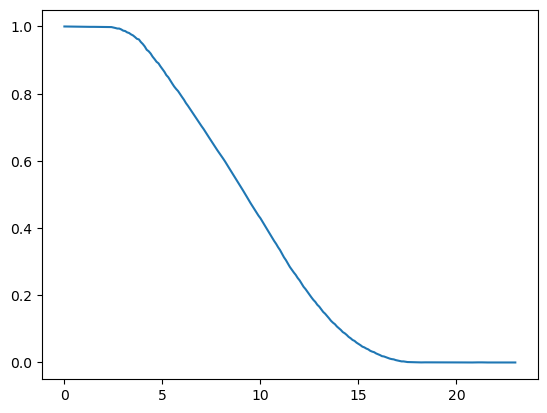

In [31]:
plt.plot(data[:,0], r(data[:,0]))